In [9]:
# Import necessary packages
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
random_state = 492026

# Read in the data
df = pd.read_csv('data/lung_cancer_data.csv')

In [10]:
# Consolidate metastasis columns
metastasis = []
for i in range(df.shape[0]):
    mets = df[["mets_at_dx_bone", "mets_at_dx_brain", "mets_at_dx_distant_ln", "mets_at_dx_liver", 
               "mets_at_dx_lung", "mets_at_dx_other"]].iloc[i].tolist()
    if "Yes" in mets:
        metastasis.append(1)
    else:
        metastasis.append(0)
df['metastasis'] = pd.Series(metastasis)
df = df.drop(columns=["mets_at_dx_bone", "mets_at_dx_brain", "mets_at_dx_distant_ln",
                   "mets_at_dx_liver", "mets_at_dx_lung", "mets_at_dx_other"])

# Recode NAs
df['rx_summ_chemo'] = df['rx_summ_chemo'].fillna("No Chemo")
df['rx_summ_immunotherapy'] = df['rx_summ_immunotherapy'].fillna("No Immuno")

df

,year_of_diagnosis,dx_lastcontact_death_months,puf_vital_status,puf_case_id,puf_facility_id,facility_type_cd,facility_location_cd,age,sex,race,...,laterality,histology,regional_nodes_positive,analytic_stage_group,tumor_size_summary_2016,rx_summ_surg_prim_site,rx_summ_chemo,rx_summ_immunotherapy,rx_summ_surgrad_seq,metastasis
0,2018,1.120000,Dead,D00002e7d-bb34-46e6-849e-6c4f0acef147,RNYCFBVPLK,Community Cancer Program,South Atlantic,71.0,Male,White,...,Origin of primary is left,Squamous cell carcinoma,No nodes were examined,Stage IV,94.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,1
1,2019,34.070000,Dead,D00002f04-3dd7-4234-bb33-84f3a20b86c9,PSAHKJHEIG,Comprehensive Community Cancer Program,Pacific,90.0,Female,Black,...,Origin of primary is right,Squamous cell carcinoma,No nodes were examined,Stage IV,28.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,1
2,2019,21.450001,Dead,D0000690b-4418-4162-bc8e-2d62701c93ca,GQSMCSUAOK,Community Cancer Program,East North Central,80.0,Female,White,...,Origin of primary is right,Squamous cell carcinoma,No nodes were examined,Stage III,12.0,No surgery,Multiagent chemotherapy,No Immuno,No radiation therapy and/or surgical procedures,0
3,2022,1.380000,Dead,D00006b9c-dcb3-4535-a4fd-e20bd886fc9d,AUUCOIRDTB,Comprehensive Community Cancer Program,South Atlantic,80.0,Female,Other,...,Origin of primary is left,Squamous cell carcinoma,No nodes were examined,Stage IV,87.0,No surgery,No Chemo,Yes (first course therapy),No radiation therapy and/or surgical procedures,1
4,2019,40.049999,Alive,D00006dce-2eb8-498e-a6bc-da673b7a434e,CFHJPZWJNY,Integrated Network Cancer Program,West South Central,57.0,Female,White,...,Origin of primary is left,Adenocarcinoma,No nodes were examined,Stage III,70.0,No surgery,Multiagent chemotherapy,Yes (first course therapy),No radiation therapy and/or surgical procedures,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414470,2022,30.820000,Alive,Dffff6eb3-09cf-433b-9c8c-165143c8ecc8,VHTPYZBLEB,Integrated Network Cancer Program,East North Central,78.0,Male,White,...,Origin of primary is left,Adenocarcinoma,No nodes were examined,Stage I,14.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,0
414471,2020,7.360000,Dead,Dffff7a97-fd34-438d-b5b9-ca1930c78679,TXEIDOZHLI,Integrated Network Cancer Program,South Atlantic,75.0,Male,White,...,Origin of primary is right,Squamous cell carcinoma,All nodes examined are negative,Stage III,103.0,Pneumonectomy,Multiagent chemotherapy,Yes (first course therapy),No radiation therapy and/or surgical procedures,0
414472,2018,12.160000,Dead,Dffff8d6c-a1cd-4085-9846-222b943a44d3,TVXWQGNICT,Comprehensive Community Cancer Program,Pacific,61.0,Female,White,...,Origin of primary is left,Adenocarcinoma,No nodes were examined,Stage IV,46.0,No surgery,Multiagent chemotherapy,Yes (first course therapy),No radiation therapy and/or surgical procedures,1
414473,2022,1.870000,Dead,Dffffabfc-6747-43e7-86c7-9cf043363c9f,UMUHJVXWPB,Integrated Network Cancer Program,West South Central,75.0,Male,Other,...,Origin of primary is right,Adenocarcinoma,No nodes were examined,Stage IV,70.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,1


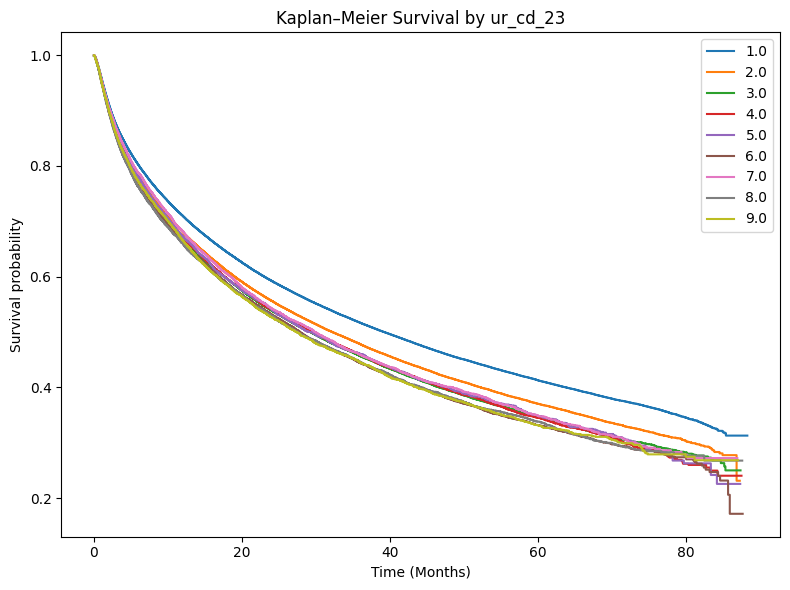

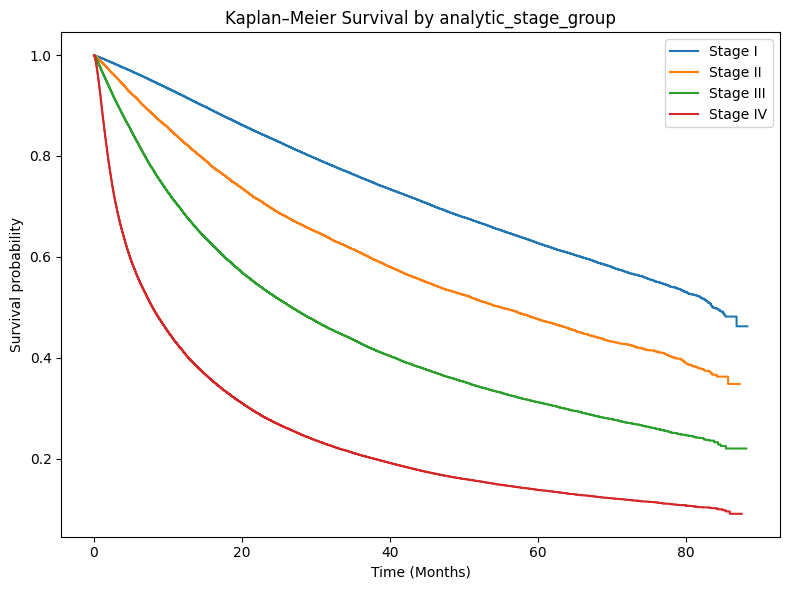

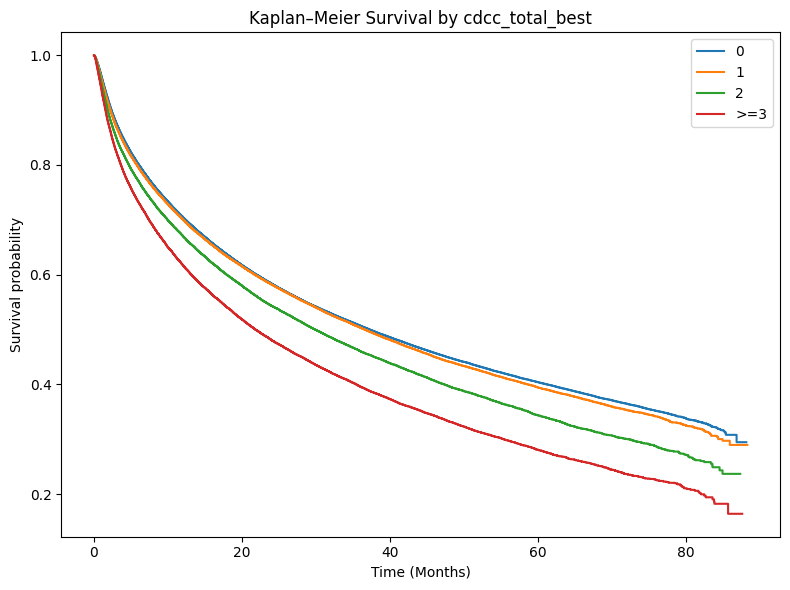

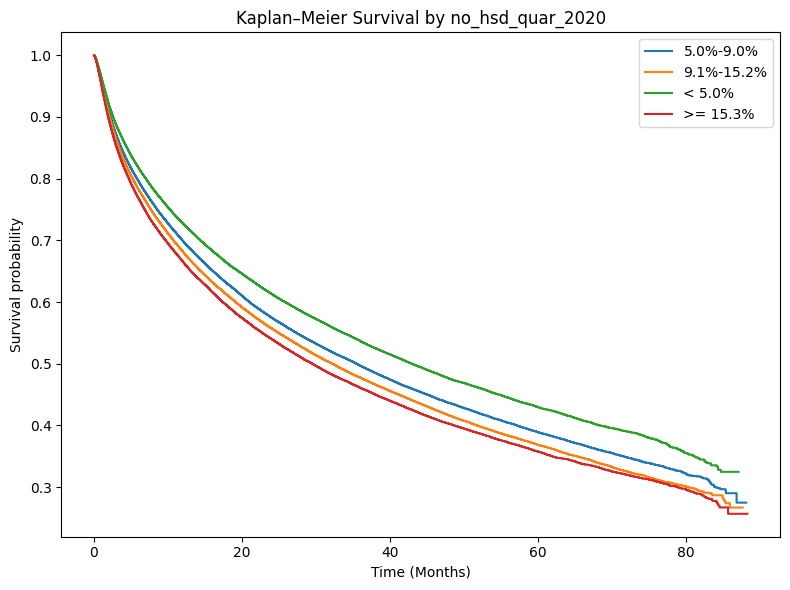

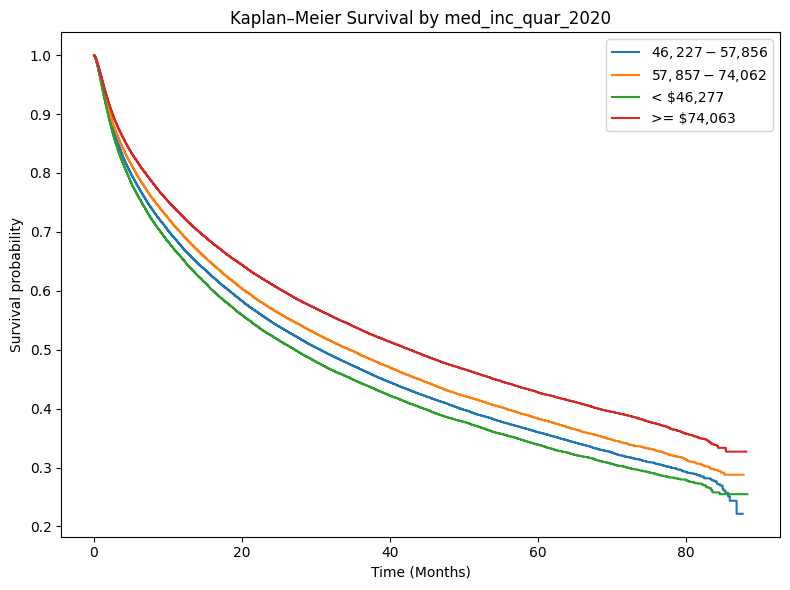

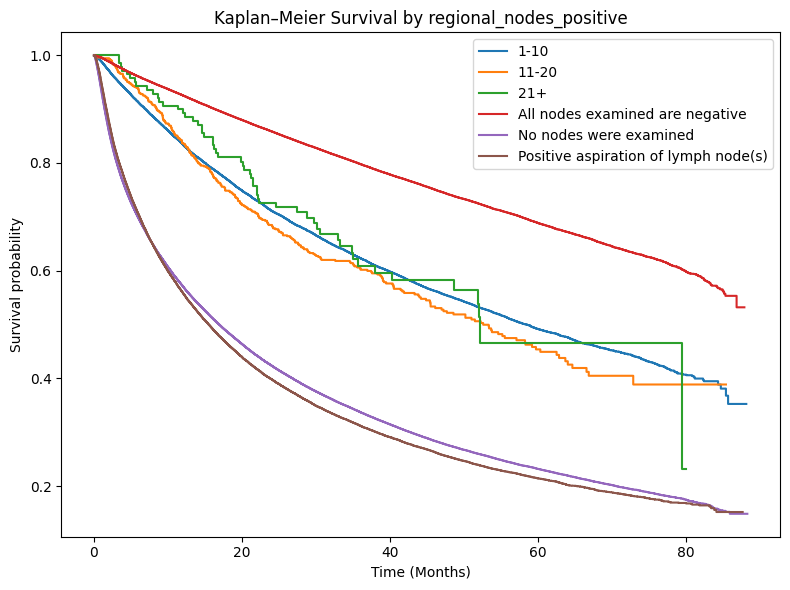

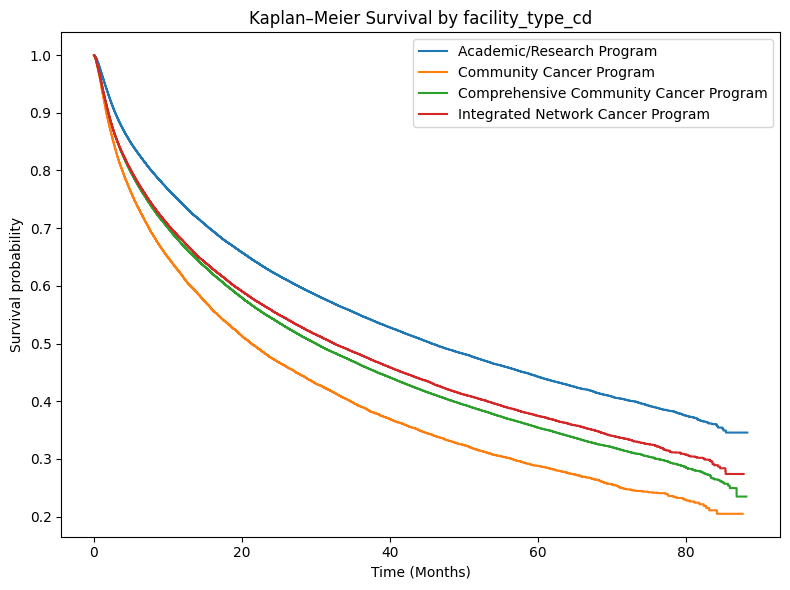

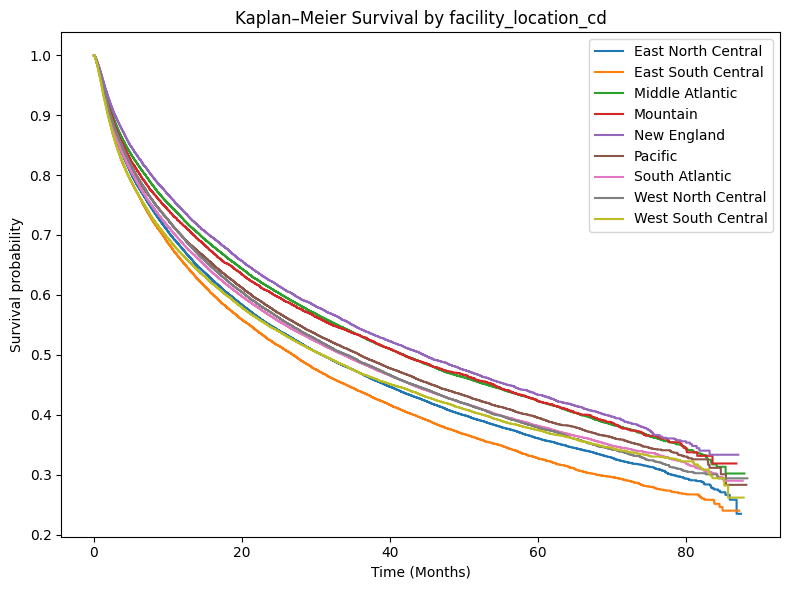

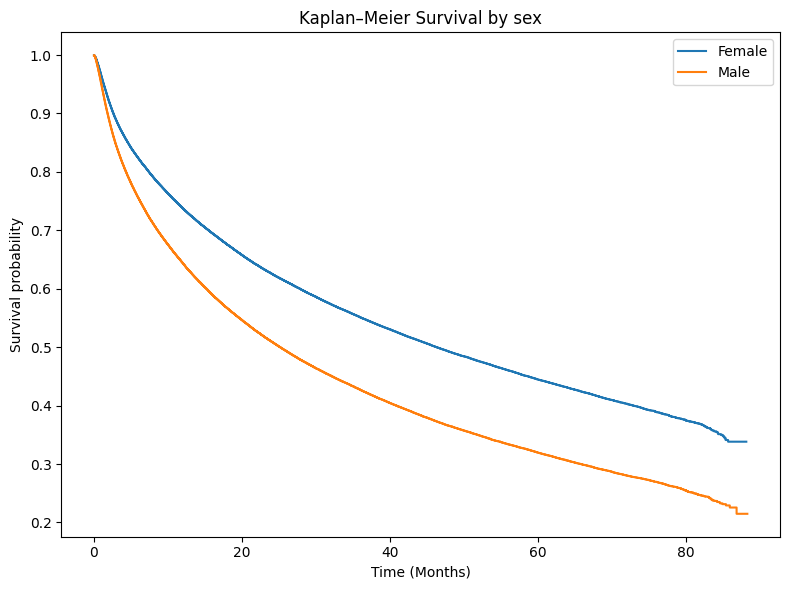

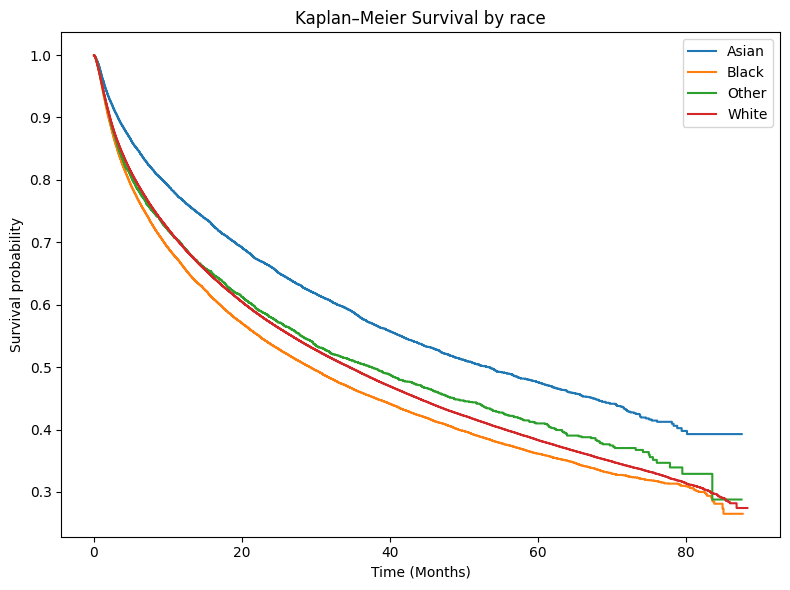

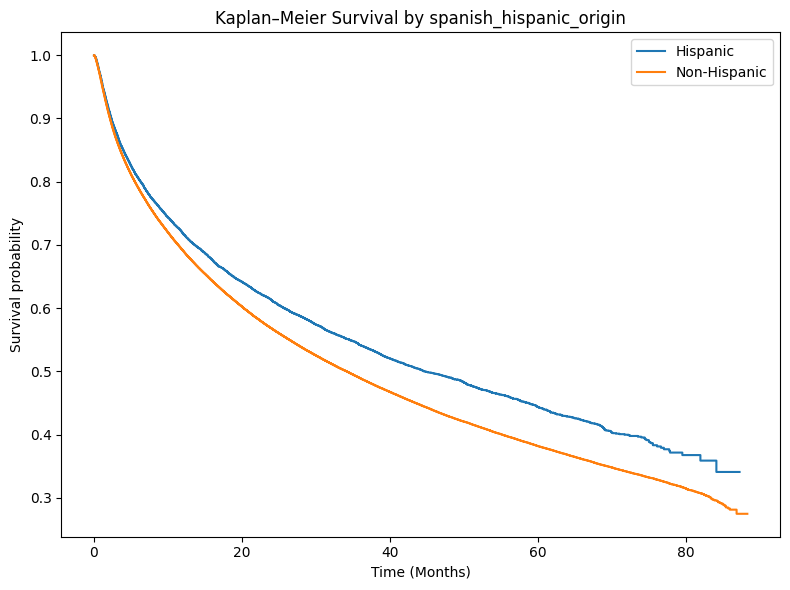

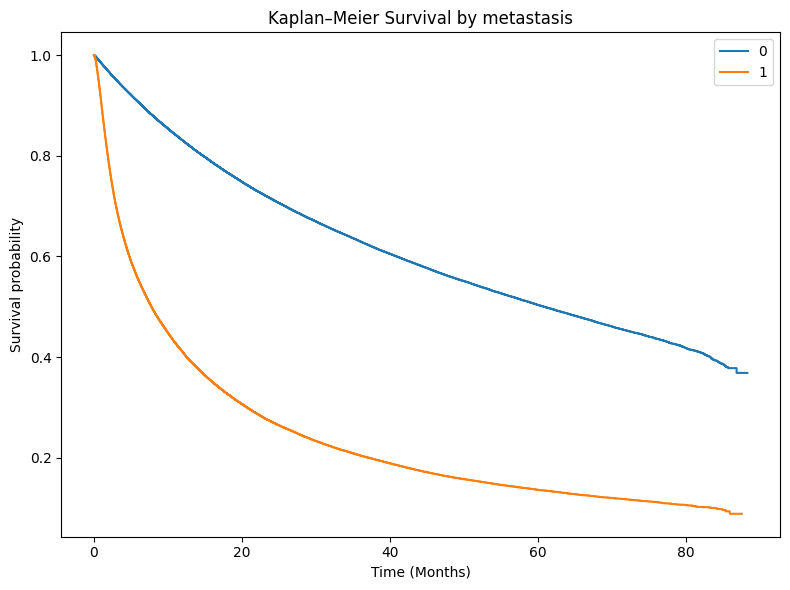

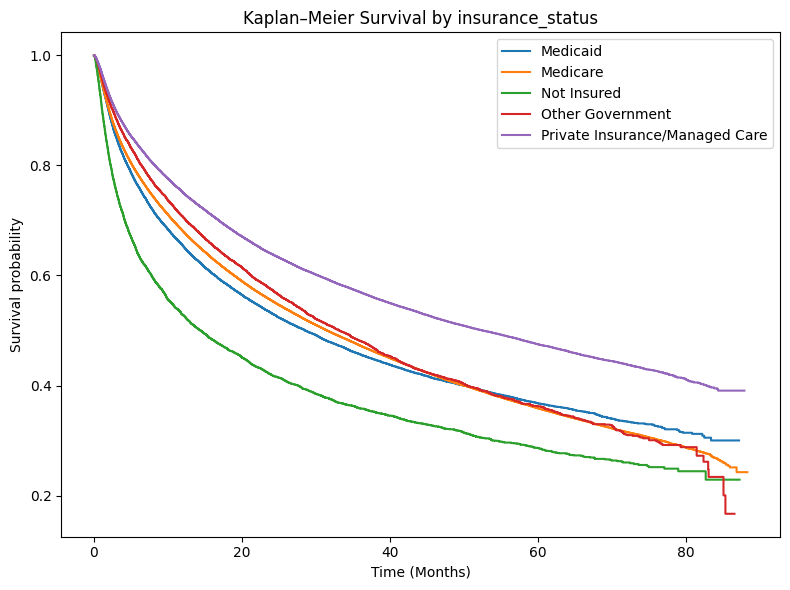

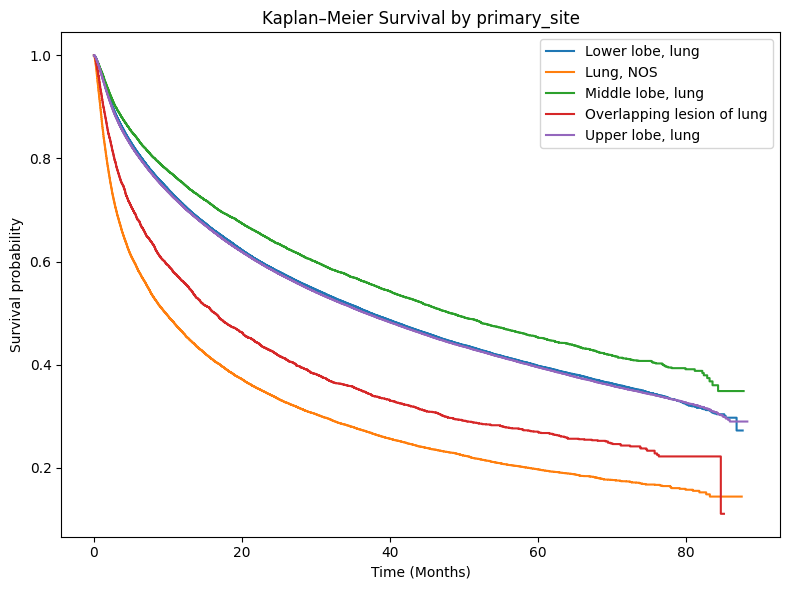

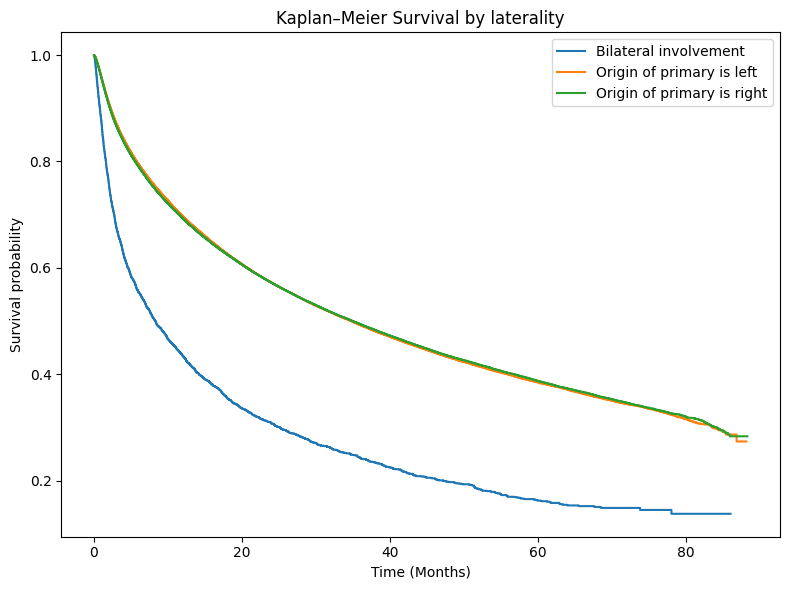

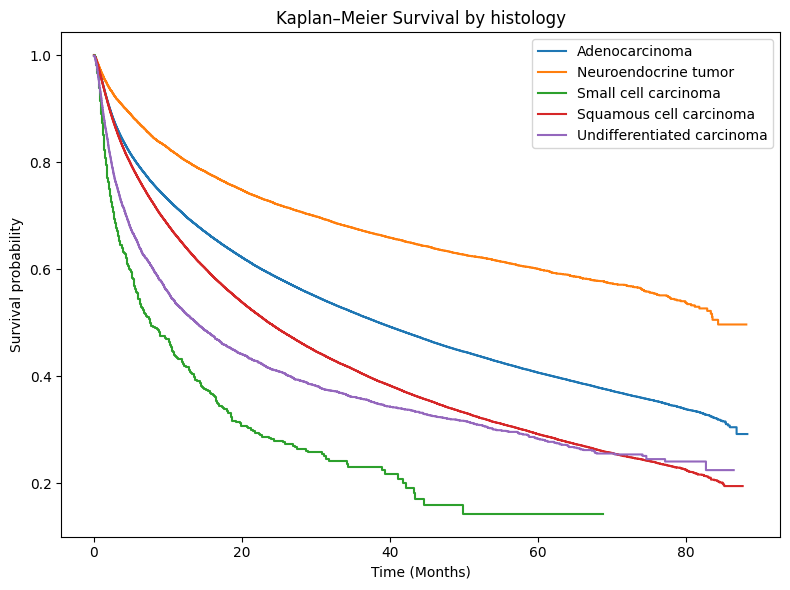

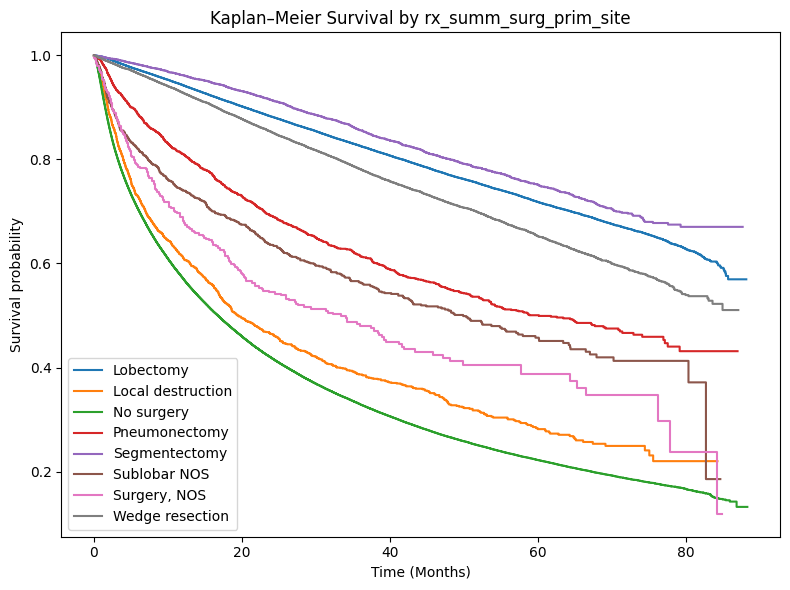

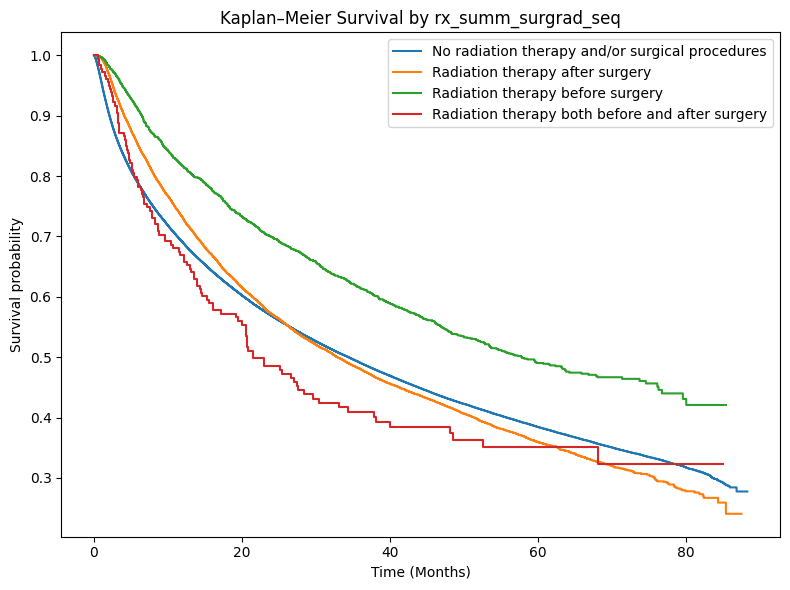

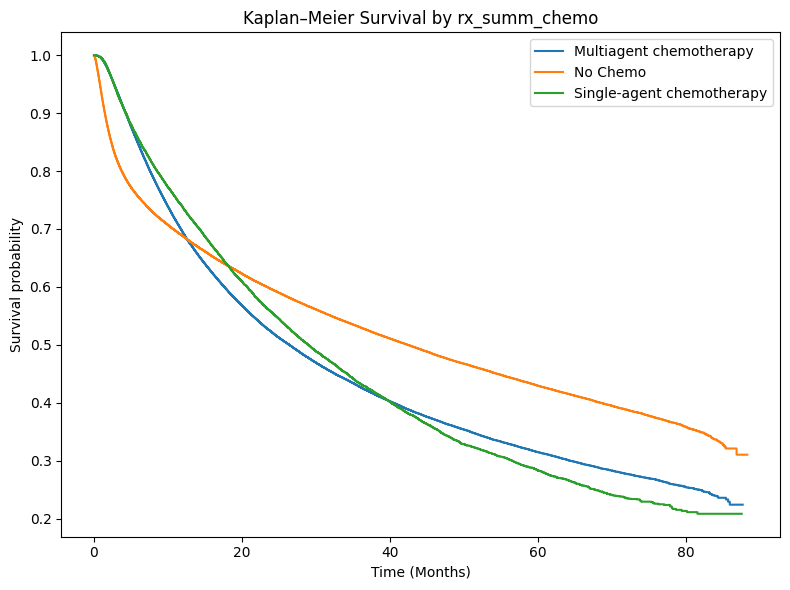

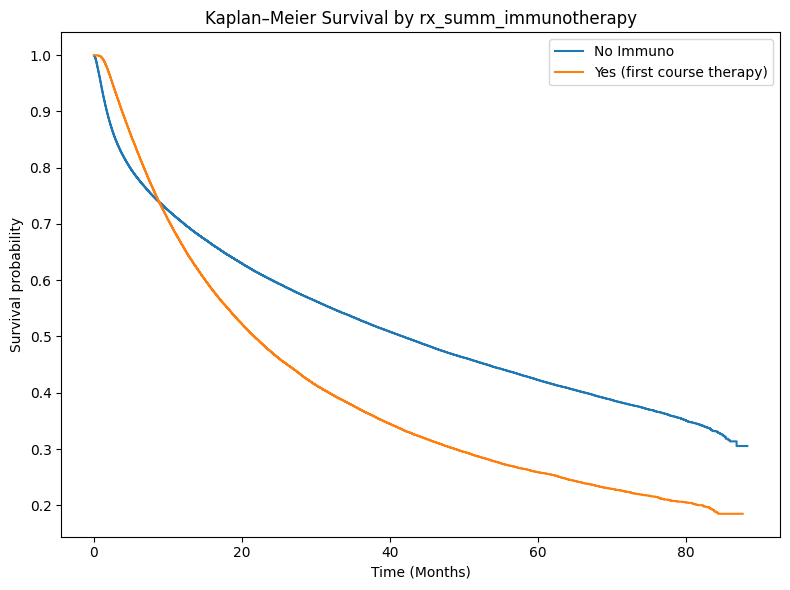

In [12]:
categorical_cols = ["ur_cd_23",
                    "analytic_stage_group",
                    "cdcc_total_best",
                    "no_hsd_quar_2020",
                    "med_inc_quar_2020",
                    "regional_nodes_positive",
                    "facility_type_cd",
                    "facility_location_cd",
                    "sex",
                    "race",
                    "spanish_hispanic_origin",
                    "metastasis",
                    "insurance_status",
                    "primary_site",
                    "laterality",
                    "histology",
                    "rx_summ_surg_prim_site",
                    "rx_summ_surgrad_seq",
                    "rx_summ_chemo",
                    "rx_summ_immunotherapy"]

# Perform a cleaning step
df['puf_vital_status_binary'] = df["puf_vital_status"].map({'Dead':1, 'Alive':0})

# Plot KM curves
for col in categorical_cols:
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))
    for level in sorted(df[col].unique()):
        mask = df[col] == level
        kmf.fit(
            durations=df.loc[mask, "dx_lastcontact_death_months"],
            event_observed=df.loc[mask, "puf_vital_status_binary"],
            label=f"{level}"
        )
        kmf.plot(ci_show=False)
    plt.title(f"Kaplan–Meier Survival by {col}")
    plt.xlabel("Time (Months)")
    plt.ylabel("Survival probability")
    plt.legend()
    plt.tight_layout()
    plt.show()